In [2]:
%pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.ticker as ticker
import numpy as np

#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
import matplotlib as mpl
from matplotlib import font_manager, rc

#mac
font_name = font_manager.FontProperties(fname="/System/Library/Fonts/Supplemental/AppleGothic.ttf").get_name()
rc('font', family=font_name)

#윈도우
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name)


#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
mpl.rcParams['axes.unicode_minus'] = False

# title = '연도별 가구 구성 세대 변화'
# plt.savefig(title.replace(' ', '_'))

In [105]:
# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/household')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfg = pd.read_sql("SELECT * FROM 15_23generation", engine, index_col=None)

# 'generation' 열을 인덱스로 설정
dfg.set_index('generation', inplace=True)

# 결과 출력
dfg

,2015y,2016y,2017y,2018y,2019y,2020y,2021y,2022y,2023y
generation,,,,,,,,,
1g,3324418,3329335,3470070,3600264,3752000,3893435,4054467,4172590,4198385
2g,9328293,9361705,9320588,9288450,9209885,9201530,9049887,8918035,8857422
3g,1029196,998919,946500,893501,839928,759548,701095,662460,639542
4plus,11262,10678,9381,8012,6891,5384,4566,4183,3766
1p,5203440,5397615,5618677,5848594,6147516,6643354,7165788,7502350,7829035
ng,214421,269444,308659,340367,386968,423459,472660,513889,545008
total,19111030,19367696,19673875,19979188,20343188,20926710,21448463,21773507,22073158


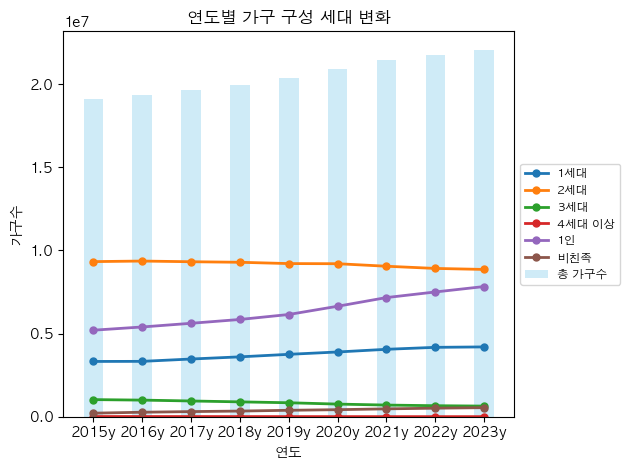

In [68]:
# 연도별 가구 구성 세대 변화

# 연도별로  가구를 구성하는 세대의 변화를 알아보고 싶어 2015년 부터 2023년까지의 그래프를 그려봤습니다. 
# 그러나 전체 표본수가 증가해서 각각의 가구들이 어떻게 변화하는지 정확히 파악하기기 힘듭니다.

# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/household')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfg = pd.read_sql("SELECT * FROM 15_23generation", engine, index_col=None)

# 'generation' 열을 인덱스로 설정
dfg.set_index('generation', inplace=True)

# 그래프 그리기
x = np.arange(len(dfg.columns))  # 연도를 x축 값으로 변환

# 총 가구수 막대 그래프
plt.bar(x, dfg.loc['total'], color='skyblue', alpha=0.4, width=0.4, label='총 가구수')  # alpha로 투명도 조정, width로 막대 너비 조정
plt.xticks(x, dfg.columns)

# 유효한 연도와 세대 라벨 설정
years = dfg.columns.tolist()  # 연도 리스트 생성
labels = dfg.index.tolist()   # 세대 리스트 생성
labels_kr = ['1세대', '2세대', '3세대', '4세대 이상', '1인', '비친족']  # 한글 라벨 리스트

# 각 세대별 선 그래프 그리기
for label, label_kr in zip(labels, labels_kr):
    if label != 'total':  # 총 가구수 제외하고 선 그래프 그리기
        plt.plot(years, dfg.loc[label, years], label=label_kr, linewidth=2, marker='o', markersize=5)

# 그래프 레이블 설정
plt.xlabel('연도')
plt.ylabel('가구수')

# 범례 위치 및 크기 조정
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# 그래프 제목 설정
plt.title('연도별 가구 구성 세대 변화')

# 레이아웃 조정 및 그래프 출력
plt.tight_layout()  # 그래프 요소가 잘리지 않도록 레이아웃 조정

title = '연도별 가구 구성 세대 변화'
plt.savefig(title.replace(' ', '_'))

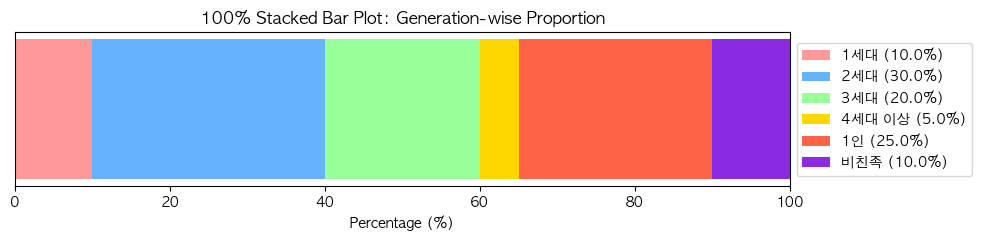

In [41]:
# 누적 막대 예시
data = {'Generation': ['1세대', '2세대', '3세대', '4세대 이상', '1인', '비친족'],
        'Count': [100, 300, 200, 50, 250, 100]}

df = pd.DataFrame(data)

# 전체 값의 합계 계산
total = df['Count'].sum()

# 백분율 계산
df['Percentage'] = (df['Count'] / total) * 100

# 누적 백분율을 위한 변수 초기화
cumulative_percentage = 0

# 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 2))  # 가로로 긴 형태의 그래프
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FF6347', '#8A2BE2']  # 색상 리스트

# 각 세대별 백분율을 누적하여 한 막대 안에 그리기
for i, (gen, percentage) in enumerate(zip(df['Generation'], df['Percentage'])):
    ax.barh(0, percentage, left=cumulative_percentage, height=0.5, color=colors[i], label=f'{gen} ({percentage:.1f}%)')
    cumulative_percentage += percentage  # 누적 백분율 업데이트

# 그래프 레이블 설정
ax.set_xlabel('Percentage (%)')
ax.set_title('100% Stacked Bar Plot: Generation-wise Proportion')
ax.set_xlim(0, 100)  # x축 범위를 0%에서 100%로 설정
ax.set_yticks([])  # y축 라벨 제거 (막대 하나만 그리므로)

# 범례 추가
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# 그래프 출력
plt.show()

                2015y      2016y      2017y      2018y      2019y      2020y  \
generation                                                                     
1g          17.395284  17.190145  17.637959  18.020072  18.443520  18.605098   
2g          48.811043  48.336699  47.375456  46.490628  45.272575  43.970266   
3g           5.385351   5.157655   4.810949   4.472159   4.128792   3.629562   
4plus        0.058929   0.055133   0.047683   0.040102   0.033874   0.025728   
1p          27.227418  27.869164  28.559076  29.273432  30.219039  31.745812   
ng           1.121975   1.391203   1.568878   1.703608   1.902199   2.023534   

                2021y      2022y      2023y  
generation                                   
1g          18.903299  19.163610  19.020319  
2g          42.193639  40.958193  40.127570  
3g           3.268742   3.042505   2.897374  
4plus        0.021288   0.019211   0.017061  
1p          33.409331  34.456323  35.468577  
ng           2.203701   2.360157   2.

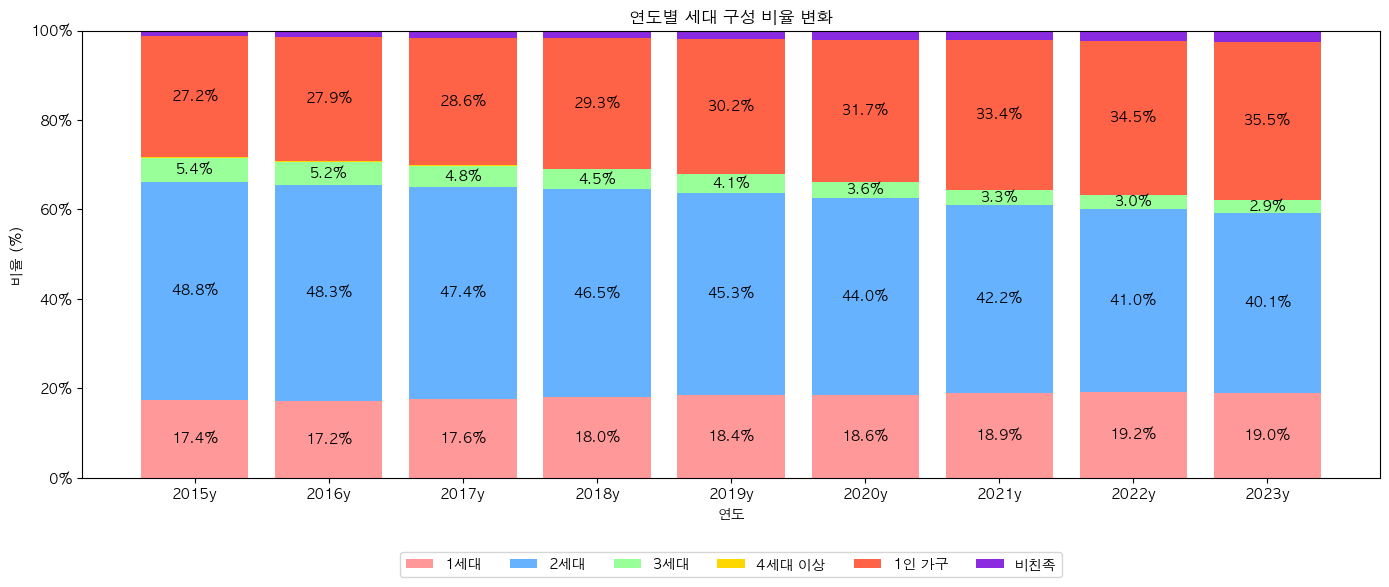

In [72]:
# 연도별 세대구성 비율 변화

# 위와 같은 이유로 정확한 세대 구성 비율을 파악하기위해 백문율로 변환 후 누적 막대 그래프 형식으로 시각화 하였습니다.

# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/household')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfg = pd.read_sql("SELECT * FROM 15_23generation", engine, index_col=None)

# 'generation' 열을 인덱스로 설정
dfg.set_index('generation', inplace=True)

# 'total' 행을 기준으로 비율 계산 후 'total' 행 제거
dfg_percent = dfg.div(dfg.loc['total'], axis=1) * 100  # 각 세대의 연도별 비율 계산
dfg_percent.drop('total', inplace=True)  # 'total' 행 제거

# 결과 출력 확인
print(dfg_percent)

# 세대별 한글 라벨 설정
labels_kr = ['1세대', '2세대', '3세대', '4세대 이상', '1인 가구', '비친족']
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FF6347', '#8A2BE2']  # 파스텔 색상

# 연도 리스트 생성
years = dfg_percent.columns.tolist()  # '2015y', '2016y' 등 연도 리스트 생성

# 연도별 누적 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 6))
bottoms = np.zeros(len(years))  # 초기 누적값 설정

# 각 세대별 막대 그래프 그리기
for idx, (label, label_kr, color) in enumerate(zip(dfg_percent.index, labels_kr, colors)):
    plt.bar(years, dfg_percent.loc[label], bottom=bottoms, color=color, label=label_kr)
    
    # 각 세대별 비율을 텍스트로 표시 (비친족과 4세대 이상은 제외)
    for i, year in enumerate(years):
        percentage = dfg_percent.loc[label, year]
        if label in ['ng', '4plus']:
            continue  # 비친족과 4세대 이상은 텍스트 생략
        plt.text(year, bottoms[i] + percentage / 2, f'{percentage:.1f}%', ha='center', va='center', fontsize=10)

    # 누적값 업데이트
    bottoms += dfg_percent.loc[label].values

# y축 설정 및 그래프 레이블 지정
ax.set_ylim([0, 100])
plt.xlabel('연도')
plt.ylabel('비율 (%)')
plt.title('연도별 세대 구성 비율 변화')

# y축을 % 단위로 표시
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 범례 위치 설정
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6)

# 그래프 여백 설정 및 출력
plt.tight_layout()

title = '연도별 세대 구성 비율 변화'
plt.savefig(title.replace(' ', '_'))

In [145]:
# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/household')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfh = pd.read_sql("SELECT * FROM 15_23household_size", engine, index_col=None)

# 'generation' 열을 인덱스로 설정
dfh.set_index('household_size', inplace=True)

# 결과 출력
dfh

,2015y,2016y,2017y,2018y,2019y,2020y,2021y,2022y,2023y
household_size,,,,,,,,,
1p,5203440.0,5397615.0,5618677.0,5848594.0,6147516.0,6643354.0,7165788.0,7502350.0,7829035.0
2p,4993818.0,5067166.0,5260332.0,5445691.0,5663330.0,5864525.0,6076549.0,6260692.0,6346314.0
3p,4100979.0,4151701.0,4178641.0,4203792.0,4217736.0,4200629.0,4169956.0,4184540.0,4194554.0
4p,3588931.0,3551410.0,3473897.0,3396320.0,3300114.0,3271315.0,3154286.0,3010697.0,2926453.0
5p,940413.0,924373.0,886479.0,849167.0,801048.0,761417.0,715982.0,664666.0,636293.0
6p,217474.0,211475.0,197517.0,182886.0,166866.0,147172.0,132665.0,120747.0,113086.0
7plus,65975.0,63956.0,58332.0,52738.0,46578.0,38298.0,33237.0,29815.0,27423.0
avg,2.5,2.5,2.5,2.4,2.4,2.3,2.3,2.2,2.2
total,19111030.0,19367696.0,19673875.0,19979188.0,20343188.0,20926710.0,21448463.0,21773507.0,22073158.0


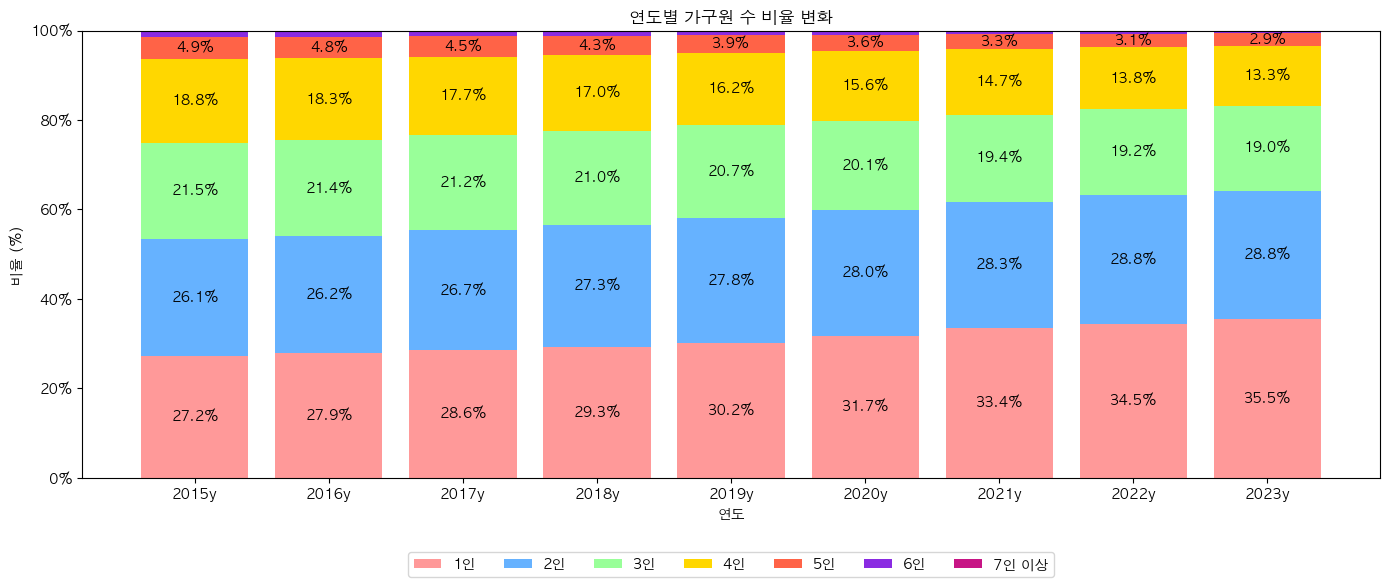

In [76]:
# 연도별 가구원 수 비율 변화

# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/household')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfh = pd.read_sql("SELECT * FROM 15_23household_size", engine, index_col=None)

# 'household_size' 열을 인덱스로 설정
dfh.set_index('household_size', inplace=True)

# 'avg' 행 제거
dfh.drop('avg', inplace=True)

# 'total' 행을 기준으로 비율 계산 후 'total' 행 제거
dfh_percent = dfh.div(dfh.loc['total'], axis=1) * 100  # 각 세대의 연도별 비율 계산
dfh_percent.drop('total', inplace=True)  # 'total' 행 제거

# 세대별 한글 라벨 설정
labels_kr = ['1인', '2인', '3인', '4인', '5인', '6인', '7인 이상']
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FF6347', '#8A2BE2', '#C71585']  # 색상 재조정

# 연도 리스트 생성
years = dfh_percent.columns.tolist()  # '2015y', '2016y' 등 연도 리스트 생성

# 연도별 누적 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 6))
bottoms = np.zeros(len(years))  # 초기 누적값 설정

# 각 세대별 막대 그래프 그리기
for idx, (label, label_kr, color) in enumerate(zip(dfh_percent.index, labels_kr, colors)):  # dfh_percent.index 사용
    plt.bar(years, dfh_percent.loc[label], bottom=bottoms, color=color, label=label_kr)
    
    # 각 세대별 비율을 텍스트로 표시 (2% 미만인 경우 생략)
    for i, year in enumerate(years):
        percentage = dfh_percent.loc[label, year]
        
        # 비율이 2% 미만일 때 텍스트를 생략
        if percentage < 2:
            continue
        
        # 비율이 2% 이상일 때만 텍스트 표시
        plt.text(year, bottoms[i] + percentage / 2, f'{percentage:.1f}%', ha='center', va='center', fontsize=10)

    # 누적값 업데이트
    bottoms += dfh_percent.loc[label].values

# y축 설정 및 그래프 레이블 지정
ax.set_ylim([0, 100])
plt.xlabel('연도')
plt.ylabel('비율 (%)')
plt.title('연도별 가구원 수 비율 변화')

# y축을 % 단위로 표시
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 범례 위치 설정
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=7)

# 그래프 여백 설정 및 출력
plt.tight_layout()

title = '연도별 가구원 수 비율 변화'
plt.savefig(title.replace(' ', '_'))

In [82]:
# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/p_food')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfa = pd.read_sql("SELECT * FROM 18_22agri_p_price", engine, index_col=None)

# 'generation' 열을 인덱스로 설정
dfa.set_index('unit_1000', inplace=True)

# 결과 출력
dfa

,2018y,2019y,2020y,2021y,2022y
unit_1000,,,,,
total,3150068950,3260799233,3458322208,3951612914,4580837558
starch,161734336,173370629,185346494,257765967,344309769
starch_p,94453132,101573515,92885775,106713088,120603865
flour,1046072735,1015157667,995903064,1046176688,1389965436
e_flour,229646,3079935,2872716,3085988,4045882
p_butter,4556295,4514392,4943726,5034590,5389154
nut_p,386289922,350825497,411076001,470623062,462422080
cereals,156103768,182159386,190790640,183709832,184514909
s_rice,469986,685373,747021,624262,451162


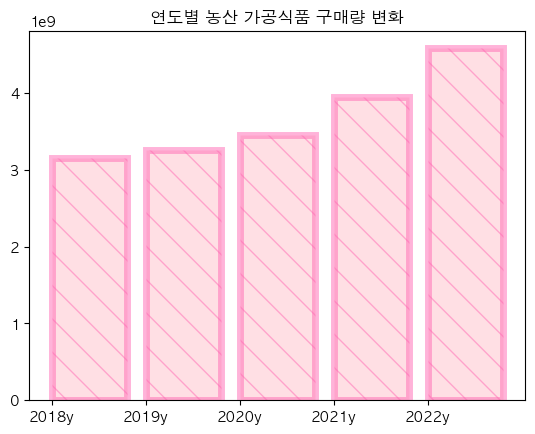

In [39]:
# 연도별 농산 가공식품 구매량 변화

# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/p_food')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfa = pd.read_sql("SELECT * FROM 18_22agri_p_price", engine, index_col=None)

# 'generation' 열을 인덱스로 설정
dfa.set_index('unit_1000', inplace=True)

years = dfa.columns.values# years = ['2018', '2019', '2020']
values = dfa.loc['total'].values# values = [100, 400, 900]

plt.bar(years, values, alpha = 0.5 ,color = 'pink', align = 'edge', edgecolor='hotpink',
        linewidth=5, tick_label=years, hatch='\\')
# {'/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*'} 채우기 옵션

plt.title('연도별 농산 가공식품 구매량 변화')

title = '연도별농산가공식품구매량변화'
# plt.savefig(title.replace(' ', '_'))
plt.show()

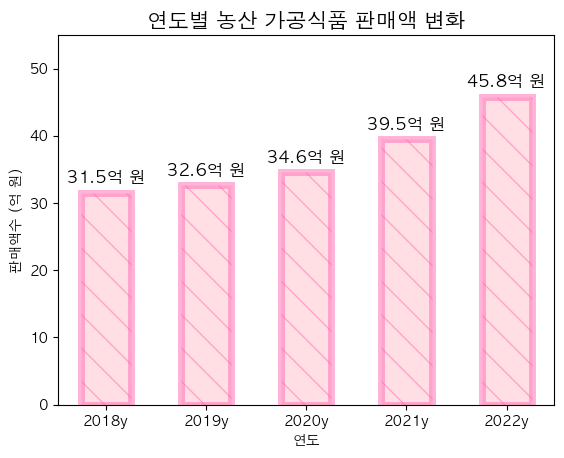

In [59]:
# 연도별 농산 가공식품 판매액 변화

# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/p_food')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfa = pd.read_sql("SELECT * FROM 18_22agri_p_price", engine, index_col=None)

# 'unit_1000' 열을 인덱스로 설정
dfa.set_index('unit_1000', inplace=True)

# 연도 및 값 설정
years = dfa.columns.values  # 예: ['2018', '2019', '2020']
values = dfa.loc['total'].values  # 총액 값 가져오기

# 억 단위로 변환
values_in_100millions = values / 1e8  # 1억으로 나누어 억 단위로 변환

# 막대 그래프 생성
bar_width = 0.5  # 막대 너비 조정
plt.bar(years, values_in_100millions, alpha=0.5, color='pink', width=bar_width, edgecolor='hotpink',
        linewidth=5, tick_label=years, hatch='\\')

# 라벨 추가: 'xx억 원' 형식으로 표기
for i, value in enumerate(values_in_100millions):
    plt.text(i, value + 1, f'{value:.1f}억 원', ha='center', va='bottom', fontsize=12, color='black')

# 제목 및 축 설정
plt.title('연도별 농산 가공식품 판매액 변화', fontsize=15)
plt.ylabel('판매액수 (억 원)')
plt.xlabel('연도')
plt.ylim(0, max(values_in_100millions) * 1.2)  # y축 범위를 억 단위로 설정하여 라벨 공간 확보

# x축과 라벨이 일치하도록 위치 조정
plt.xticks([i for i in range(len(years))], years)

# 그래프 저장
title = '연도별농산가공식품구매량변화'
plt.savefig(title.replace(' ', '_'))

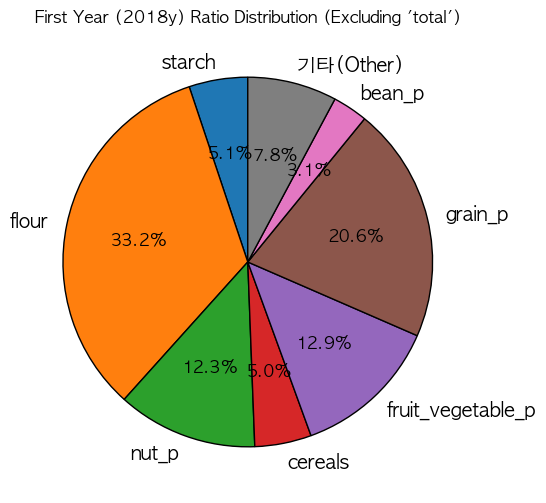

In [51]:
# 18년 가공식품 구매율 임시

import matplotlib.pyplot as plt

# 'total' 행을 제외한 첫 번째 열의 값만 선택
ratio = dfa.iloc[1:, 0] / dfa.iloc[0, 0]  # 첫 번째 열의 값을 'total' 행의 첫 번째 열 값으로 나누기
labels = dfa.index[1:]  # 'total' 행을 제외한 나머지 행 인덱스 설정

# 비율이 5% 미만인 항목을 '기타(Other)'로 합치기
threshold = 0.03  # 비율이 5% 미만이면 기타로 합침
ratio_filtered = []
labels_filtered = []
other_sum = 0

for i, val in enumerate(ratio):
    if val >= threshold:
        ratio_filtered.append(val)
        labels_filtered.append(labels[i])
    else:
        other_sum += val

# '기타' 비율 추가
if other_sum > 0:
    ratio_filtered.append(other_sum)
    labels_filtered.append("기타(Other)")

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(ratio_filtered, labels=labels_filtered, autopct='%.1f%%',
                                   startangle=90, wedgeprops={'edgecolor': 'black'},
                                   textprops={'fontsize': 12})

# 글씨가 겹치지 않도록 조정
for text, autotext in zip(texts, autotexts):
    text.set_fontsize(14)  # 레이블 크기
    autotext.set_fontsize(12)  # 퍼센트 텍스트 크기

# 제목 추가
plt.title(f"First Year ({dfa.columns[0]}) Ratio Distribution (Excluding 'total')")
plt.show()

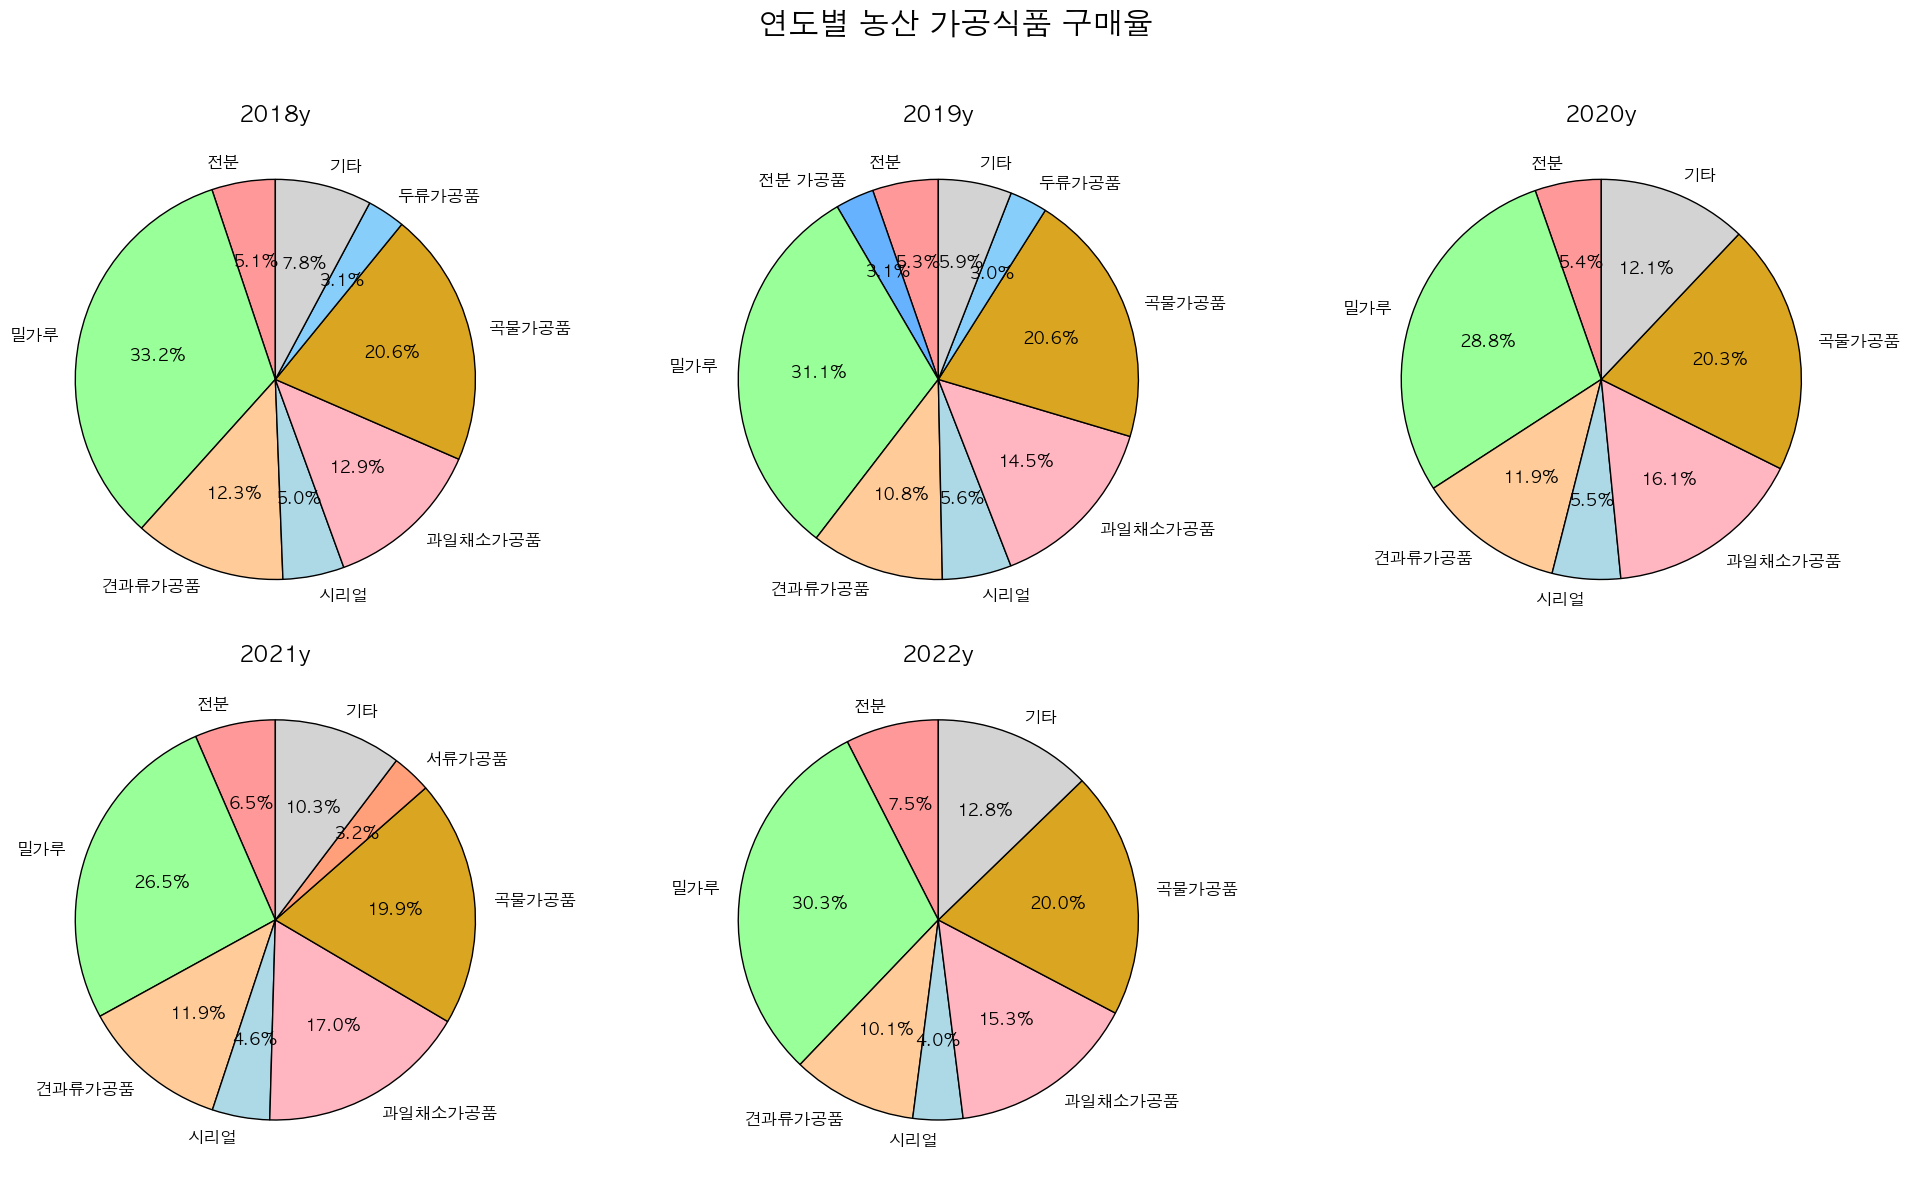

In [122]:
# 연도별 가공식품 구매율

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# MySQL 데이터베이스 연결 설정
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/p_food')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfa = pd.read_sql("SELECT * FROM 18_22agri_p_price", engine, index_col=None)

# 'unit_1000' 열을 인덱스로 설정
dfa.set_index('unit_1000', inplace=True)

# 전체 한글 라벨 리스트 (total 포함)
labels_ko = [
    "합계", "전분", "전분 가공품", "밀가루", "영양강화밀가루", "땅콩버터", "견과류가공품", "시리얼", "찐쌀",
    "효소가공품", "과일채소가공품", "곡물가공품", "두류가공품", "서류가공품", "기타"
]

# 총 데이터프레임의 행 인덱스와 한글 라벨 매칭
dfa.index = labels_ko

# 같은 품목에 대해 고정된 색상을 지정하는 색상 사전
color_map = {
    "합계": "#8B4513", "전분": "#FF9999", "전분 가공품": "#66B2FF", "밀가루": "#99FF99",
    "영양강화밀가루": "#FFD700", "땅콩버터": "#FF6347", "견과류가공품": "#FFCC99", "시리얼": "#ADD8E6",
    "찐쌀": "#D2B48C", "효소가공품": "#98FB98", "과일채소가공품": "#FFB6C1", "곡물가공품": "#DAA520",
    "두류가공품": "#87CEFA", "서류가공품": "#FFA07A", "기타": "#D3D3D3"
}

# 전체 figure 설정 (1행에 3개, 2행에 2개로 배열)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))  # 2행 3열 서브플롯 배열 (하나의 subplot은 빈 상태)

# 열의 개수에 맞는 subplot 위치 설정
positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]  # 1행 3개, 2행 2개의 서브플롯 위치 지정

# 열을 하나씩 반복하여 파이 차트 생성
for i, col in enumerate(dfa.columns):
    # '합계' 행을 제외한 비율 계산
    ratio = dfa.iloc[1:, i] / dfa.iloc[0, i]  # 각 열의 '합계'를 기준으로 비율 계산
    labels = dfa.index[1:]  # '합계' 행을 제외한 나머지 행 인덱스 설정

    # 작은 비율을 합쳐 '기타'로 표시
    threshold = 0.03  # 비율이 3% 미만이면 기타로 합침
    ratio_filtered = []
    labels_filtered = []
    other_sum = 0

    # '기타' 항목이 이미 존재하는지 확인하여 인덱스 추출
    if "기타" in labels:
        existing_other_index = labels.get_loc("기타")
        other_sum += ratio.iloc[existing_other_index]  # 기존 '기타' 값 추가

    for j, val in enumerate(ratio):
        if j == existing_other_index:
            continue  # 이미 기타에 포함된 값은 건너뜀
        if val >= threshold:
            ratio_filtered.append(val)
            labels_filtered.append(labels[j])
        else:
            other_sum += val

    # 합산된 '기타' 비율 추가
    if other_sum > 0:
        ratio_filtered.append(other_sum)
        labels_filtered.append("기타")

    # 색상 리스트 생성: labels_filtered에 맞는 색상 선택
    colors = [color_map[label] for label in labels_filtered]  # 사전에 정의된 색상 사용

    # 현재 열에 해당하는 subplot의 위치 설정
    row, col_pos = positions[i]  # subplot의 행, 열 위치를 가져옴
    wedges, texts, autotexts = axes[row, col_pos].pie(ratio_filtered, labels=labels_filtered, colors=colors,
                                                      autopct='%.1f%%', startangle=90,
                                                      wedgeprops={'edgecolor': 'black'},
                                                      textprops={'fontsize': 12})

    # 각 파이 차트에 제목 추가
    axes[row, col_pos].set_title(col, fontsize=16)

# 빈 subplot 숨기기
axes[1, 2].axis('off')  # 2행 3열의 빈 서브플롯을 숨김

# 전체 제목 추가
plt.suptitle('연도별 농산 가공식품 구매율', fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 전체 레이아웃 정리 및 제목 공간 확보

title = '연도별 가공식품 구매율1'
plt.savefig(title.replace(' ', '_'))

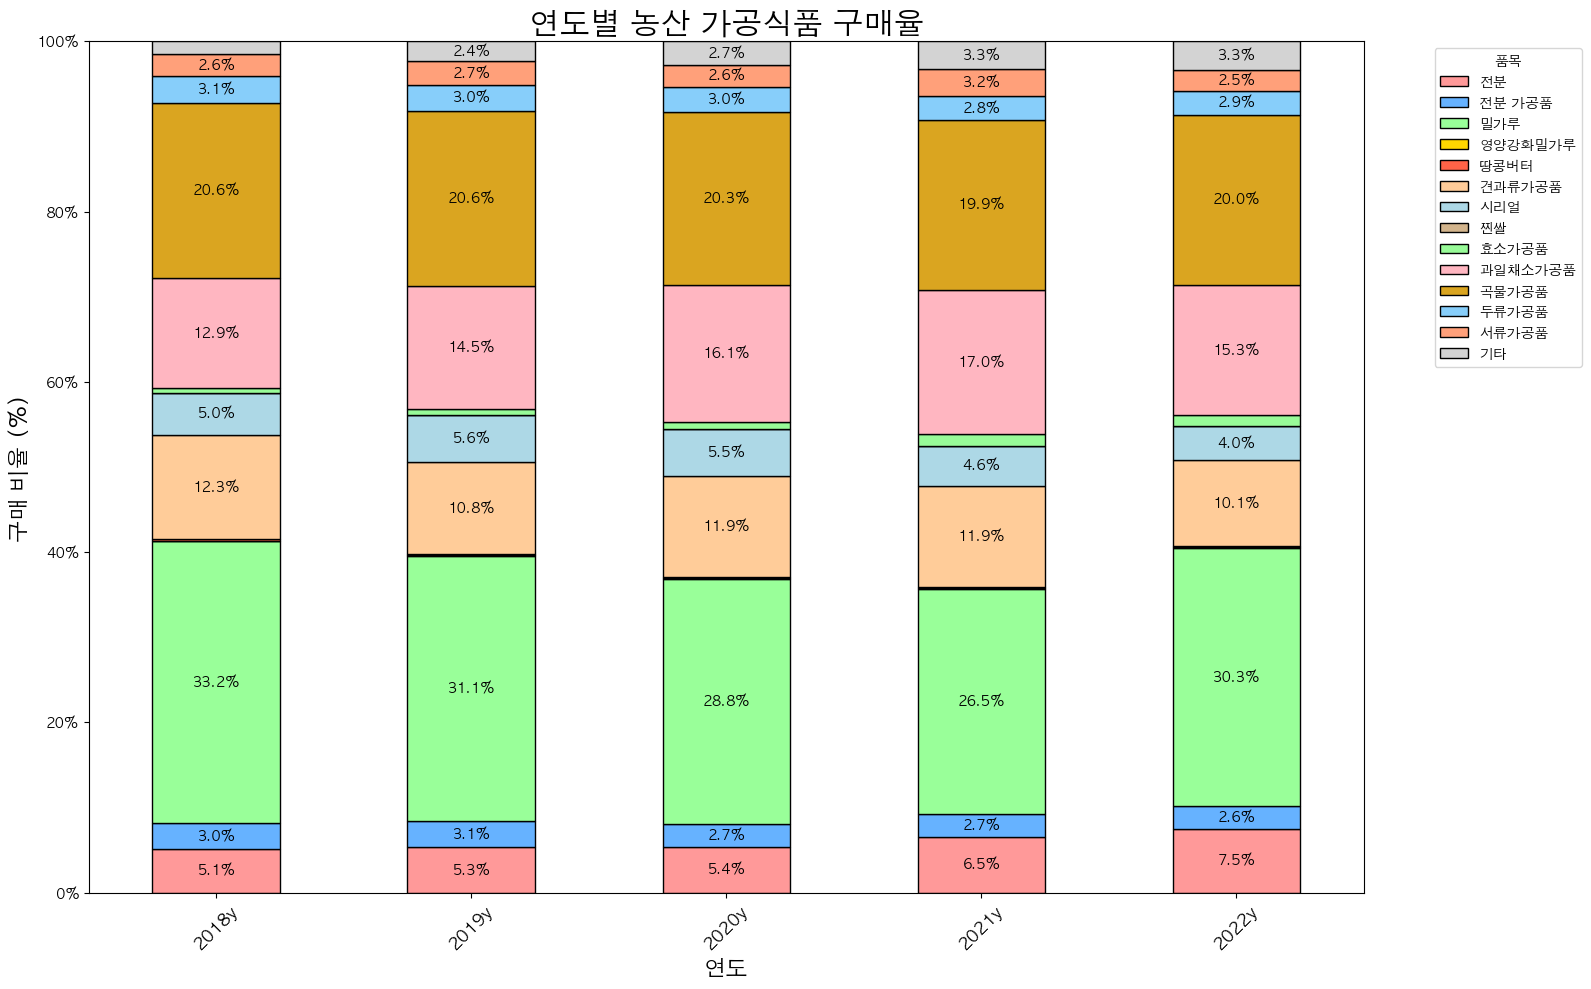

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# MySQL 데이터베이스 연결 설정
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/p_food')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfa = pd.read_sql("SELECT * FROM 18_22agri_p_price", engine, index_col=None)

# 'unit_1000' 열을 인덱스로 설정
dfa.set_index('unit_1000', inplace=True)

# 전체 한글 라벨 리스트 (total 포함)
labels_ko = [
    "합계", "전분", "전분 가공품", "밀가루", "영양강화밀가루", "땅콩버터", "견과류가공품", "시리얼", "찐쌀",
    "효소가공품", "과일채소가공품", "곡물가공품", "두류가공품", "서류가공품", "기타"
]

# 총 데이터프레임의 행 인덱스와 한글 라벨 매칭
dfa.index = labels_ko

# '합계'를 기준으로 비율 계산
df_ratio = dfa.div(dfa.loc["합계"], axis=1)

# '합계' 행을 삭제하여 각 품목의 비율만 남김
df_ratio = df_ratio.drop("합계")

# 같은 품목에 대해 고정된 색상을 지정하는 색상 사전
color_map = {
    "전분": "#FF9999", "전분 가공품": "#66B2FF", "밀가루": "#99FF99", "영양강화밀가루": "#FFD700",
    "땅콩버터": "#FF6347", "견과류가공품": "#FFCC99", "시리얼": "#ADD8E6", "찐쌀": "#D2B48C",
    "효소가공품": "#98FB98", "과일채소가공품": "#FFB6C1", "곡물가공품": "#DAA520", "두류가공품": "#87CEFA",
    "서류가공품": "#FFA07A", "기타": "#D3D3D3"
}

# 비율에 맞는 색상 리스트 생성
colors = [color_map.get(label, "#D3D3D3") for label in df_ratio.index]

# 누적 막대그래프 그리기
ax = df_ratio.T.plot(kind='bar', stacked=True, figsize=(16, 10), color=colors, edgecolor='black')

# y축을 0-100% 범위로 설정하고 y축 라벨을 %로 표시
ax.set_ylim(0, 1)  # 비율이 0에서 1 사이이므로 0-1로 설정 (100%)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y * 100)}%'))

# 그래프 제목과 축 라벨 추가
plt.title('연도별 농산 가공식품 구매율', fontsize=22)
plt.xlabel('연도', fontsize=16)
plt.ylabel('구매 비율 (%)', fontsize=16)

# 막대 위에 비율(%) 라벨 표시 (작은 비율은 제외)
for container in ax.containers:
    # 각 막대에 대해 라벨 설정
    for bar in container:
        height = bar.get_height()
        if height > 0.02:  # 3% 이상일 때만 라벨 표시
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{height * 100:.1f}%',
                ha='center', va='center', fontsize=10, color='black'
            )

# 범례 설정
plt.legend(title='품목', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, fontsize=12)  # X축 라벨 회전

# 레이아웃 조정
plt.tight_layout()

title = '연도별 가공식품 구매율2'
plt.savefig(title.replace(' ', '_'))

In [124]:
# 가구원수의 변화와 연도별 가공식품 구매량의 상관관걔 분석 시도

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 데이터 인덱스를 열로 변환
household_data = household_data.reset_index()
price_data = price_data.reset_index()

# 1인 가구 및 총 농산물 가격 데이터 추출
household_1p = household_data[household_data['household_size'] == '1p'].iloc[:, 1:].values.flatten()
total_agri_price = price_data[price_data['unit_1000'] == 'total'].iloc[:, 1:].values.flatten()

# 연도 데이터 설정
years_household = np.array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])
years_agri = np.array([2018, 2019, 2020, 2021, 2022])

# Scikit-Learn을 이용한 선형 회귀 분석
x_household = years_household.reshape(-1, 1)
x_agri = years_agri.reshape(-1, 1)

# 모델 생성 및 학습
model_household = LinearRegression()
model_household.fit(x_household, household_1p)

model_agri = LinearRegression()
model_agri.fit(x_agri, total_agri_price)

# 회귀선의 기울기와 절편 출력
a_household = model_household.coef_[0]
b_household = model_household.intercept_
print(f"1인 가구 수: 기울기 = {a_household:.4f}, 절편 = {b_household:.4f}")

a_agri = model_agri.coef_[0]
b_agri = model_agri.intercept_
print(f"농산물 가격: 기울기 = {a_agri:.4f}, 절편 = {b_agri:.4f}")

# 예측 값 생성
y_household_pred = model_household.predict(x_household)
y_agri_pred = model_agri.predict(x_agri)

# 그래프 시각화
plt.figure(figsize=(12, 5))

# 1인 가구 수 변화 그래프
plt.subplot(1, 2, 1)
plt.scatter(x_household, household_1p, label='Actual Data')
plt.plot(x_household, y_household_pred, 'r', label='Fitted Line')
plt.title("1인 가구 수 변화 (2015-2023)")
plt.xlabel("Year")
plt.ylabel("Household Size")
plt.legend()

# 농산물 가격 변화 그래프
plt.subplot(1, 2, 2)
plt.scatter(x_agri, total_agri_price, label='Actual Data')
plt.plot(x_agri, y_agri_pred, 'r', label='Fitted Line')
plt.title("농산물 가격 변화 (2018-2022)")
plt.xlabel("Year")
plt.ylabel("Agricultural Price")
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'household_data' is not defined

In [173]:
# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/p_food')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfo = pd.read_sql("SELECT * FROM 18_22online_purchase", engine, index_col=None)

# 'generation' 열을 인덱스로 설정
dfo.set_index('online_purchase', inplace=True)

# 결과 출력
dfo

,2018y,2019y,2020y,2021y,2022y
online_purchase,,,,,
major_decrease,0.80,2.3,1.00,1.80,1.00
minor_decrease,2.60,6.9,4.20,7.00,1.90
similar,77.30,69.6,65.50,60.20,71.30
minor_increase,19.10,20.9,28.90,28.10,25.40
major_increase,0.20,0.3,0.40,3.00,0.20
avg_score,3.15,3.1,3.24,3.24,3.22


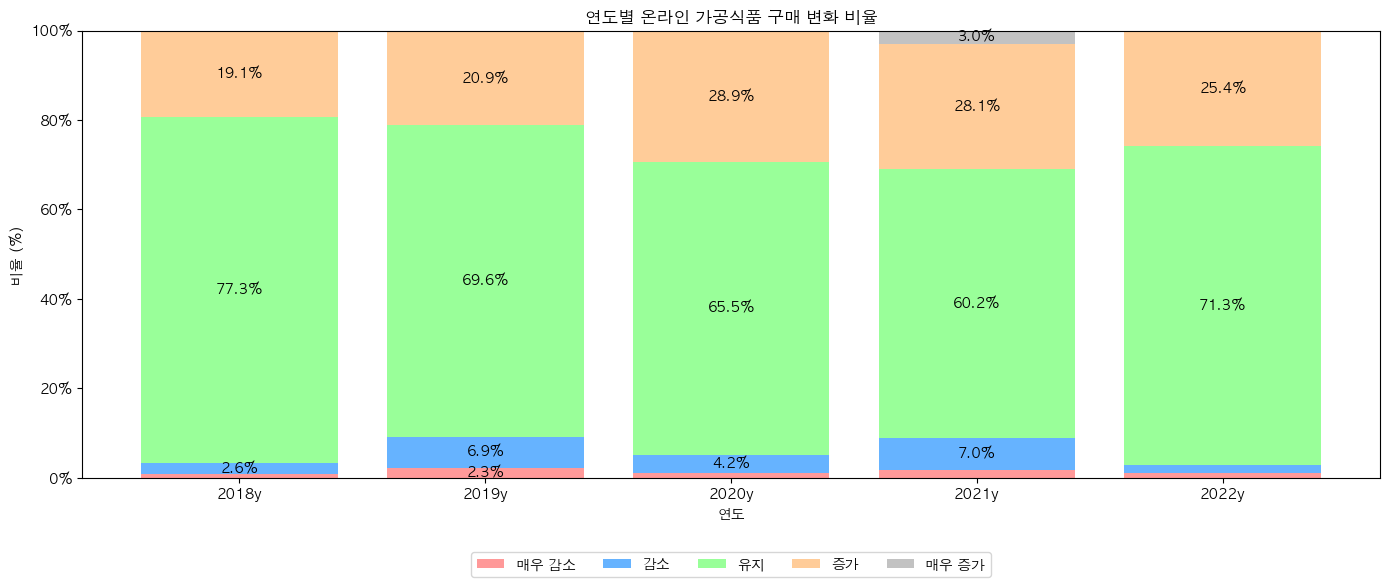

In [6]:
#연도별 온라인 가공식품 구매 비율

# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/p_food')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfo = pd.read_sql("SELECT * FROM 18_22online_purchase", engine, index_col=None)

# 'unit_1000' 열을 인덱스로 설정
dfo.set_index('online_purchase', inplace=True)

# 'avg_score' 행 제거
dfo.drop(index='avg_score', inplace=True)

# 연도 리스트 생성
years = dfo.columns.tolist()  # '2018y', '2019y' 등 연도 리스트 생성

# 연도별 누적 막대 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 6))
bottoms = np.zeros(len(years))  # 초기 누적값 설정

# 색상 및 라벨 설정
colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#C2C2C2']  # 각 카테고리별 색상 설정
labels_kr = ['매우 감소', '감소', '유지', '증가', '매우 증가']  # 카테고리별 한글 라벨

# 각 구매 변화별 막대 그래프 그리기
for idx, (label, label_kr, color) in enumerate(zip(dfo.index, labels_kr, colors)):
    plt.bar(years, dfo.loc[label], bottom=bottoms, color=color, label=label_kr)
    
    # 각 변화별 비율을 텍스트로 표시 (2% 미만인 경우 생략)
    for i, year in enumerate(years):
        percentage = dfo.loc[label, year]
        
        # 비율이 2% 미만일 때 텍스트를 생략
        if percentage < 2:
            continue
        
        # 비율이 2% 이상일 때만 텍스트 표시
        plt.text(year, bottoms[i] + percentage / 2, f'{percentage:.1f}%', ha='center', va='center', fontsize=10)

    # 누적값 업데이트
    bottoms += dfo.loc[label].values

# y축 설정 및 그래프 레이블 지정
ax.set_ylim([0, 100])
plt.xlabel('연도')
plt.ylabel('비율 (%)')
plt.title('연도별 온라인 가공식품 구매 변화 비율')

# y축을 % 단위로 표시
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 범례 위치 설정
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

# 그래프 여백 설정 및 출력
plt.tight_layout()
plt.show()

In [18]:
# SQLAlchemy를 사용하여 MySQL 연결
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/eatout')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfe = pd.read_sql("SELECT * FROM 18_24eatout", engine, index_col=None)

# 'unit_1000' 열을 인덱스로 설정
dfe.set_index('unit_10000', inplace=True)

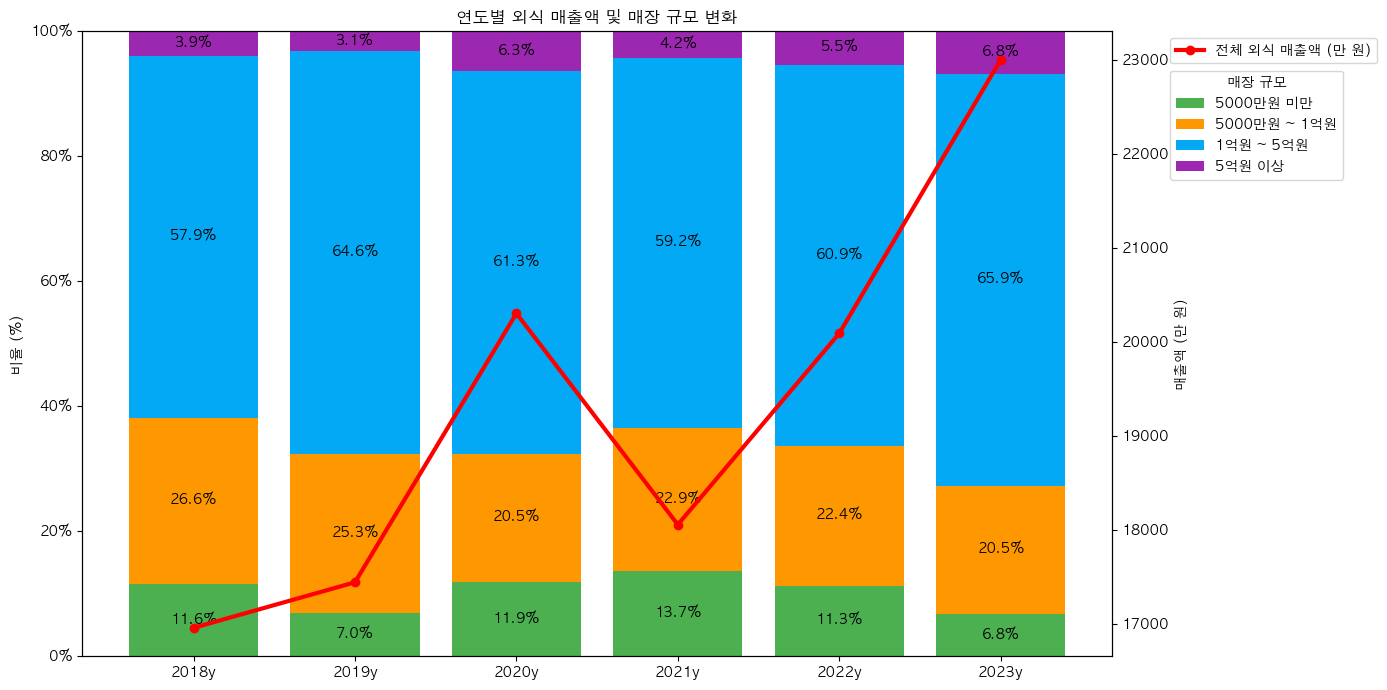

In [126]:
#외식 시각화

# SQLAlchemy를 사용하여 MySQL 연결 설정
engine = create_engine('mysql+pymysql://{USER}:{PASSWORD}@{HOST}/eatout')

# SQLAlchemy의 연결을 사용하여 read_sql() 실행
dfe = pd.read_sql("SELECT * FROM 18_24eatout", engine, index_col=None)

# 'unit_10000' 열을 인덱스로 설정
dfe.set_index('unit_10000', inplace=True)

# 데이터 분리: 누적 막대그래프용 데이터와 매출액 데이터
stack_data = dfe.loc[['less5000', '5000_10000', '10000_50000', 'over50000']]
sale_data = dfe.loc['sale']

# 소비 행태 한글 라벨 설정
korean_labels = {
    'less5000': '5000만원 미만',
    '5000_10000': '5000만원 ~ 1억원',
    '10000_50000': '1억원 ~ 5억원',
    'over50000': '5억원 이상'
}

# 데이터프레임의 인덱스를 한글 라벨로 변경
stack_data.rename(index=korean_labels, inplace=True)

# 그래프 크기 설정
fig, ax1 = plt.subplots(figsize=(14, 7))

# 연도 리스트 추출
years = stack_data.columns.tolist()

# 누적 막대그래프 색상 설정
colors = ['#4CAF50', '#FF9800', '#03A9F4', '#9C27B0']  # 각 카테고리별 고유 색상 설정

# 누적 막대그래프 그리기
bottoms = np.zeros(len(years))  # 초기 누적값 설정
for idx, (label, color) in enumerate(zip(stack_data.index, colors)):
    plt.bar(years, stack_data.loc[label], bottom=bottoms, color=color, label=label)
    
    # 각 카테고리 비율 텍스트로 표시
    for i, year in enumerate(years):
        percentage = stack_data.loc[label, year]
        plt.text(year, bottoms[i] + percentage / 2, f'{percentage:.1f}%', ha='center', va='center', fontsize=10)

    # 누적값 업데이트
    bottoms += stack_data.loc[label].values

# 첫 번째 y축 설정
ax1.set_ylabel('비율 (%)')
ax1.set_ylim([0, 100])
ax1.set_title('연도별 외식 매출액 및 매장 규모 변화')
ax1.legend(title='매장 규모', bbox_to_anchor=(1.05, 0.85), loc='center left')

# y축을 % 단위로 표시
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 두 번째 y축 설정 (매출액 꺾은선 그래프)
ax2 = ax1.twinx()
ax2.plot(sale_data.index, sale_data.values, marker='o', color='red', linestyle='-', linewidth=3, label='전체 외식 매출액 (만 원)')
ax2.set_ylabel('매출액 (만 원)')
ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))  # 매출액 범례를 소비 행태 범례 위에 표시

# x축 및 레이아웃 설정
plt.xlabel('연도')
fig.tight_layout()

# 만든 차트를 이미지 파일로 저장하는 코드
title = '연도별 외식 매출액 및 매장 규모 변화'
plt.savefig(title.replace(' ', '_'))

# 응용
# title = f'{local} 연평균 기온 및 8월~12월 평균 기온 비교'
# plt.savefig(title.replace(' ', '_'))